# Inference Time Benchmark: MLP vs LSTM-MLP vs BiLSTM-MLP (Dataset Asli)

Membuktikan secara empiris bahwa arsitektur **MLP (feed-forward)** memiliki waktu inferensi
yang lebih cepat dibandingkan arsitektur sekuensial (LSTM-MLP dan BiLSTM-MLP).

**Dataset**: dataset asli (CSV job posting) — bukan dataset sintetis  
**Cleaning pipeline**: sama persis dengan `main.ipynb` (moderate cleaning + P7 rule-based keyword mapping)  
**Feature extraction**: TF-IDF unigram+bigram, max_features=1500, min_df=5  
**Metodologi pengukuran inferensi**: `tf.function` (compiled graph), 20 warm-up run, 200 repetisi  
**Data benchmark inferensi**: SELURUH POPULASI dataset, dengan skenario batch 1 / 10 / 100 / seluruh populasi  
**Evaluasi akurasi**: `classification_report` per model, ditampilkan juga di ringkasan akhir

## 1. Setup & Imports

In [18]:
try:
    import google.colab
    from google.colab import drive

    drive.mount('/content/drive')

    dataset_path = "/content/drive/MyDrive/datasets"
    print("environtment: colab")

except ImportError:
    dataset_path = "./datasets"
    print("environtment: local")


environtment: local


In [19]:
import pandas as pd
import glob
import numpy as np
import json
import ast
import csv
import os
import time
import warnings
from collections import Counter
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')


TensorFlow : 2.16.2
NumPy      : 1.26.4


## 2. Load Dataset Asli

Load semua file CSV dari `dataset_path`, sama seperti pipeline di `main.ipynb`.

In [20]:
all_files = glob.glob(os.path.join(dataset_path, "*.csv"))

df = pd.concat([
    pd.read_csv(
        f,
        engine="python",
        quoting=csv.QUOTE_MINIMAL,
        on_bad_lines="skip"
    )
    for f in all_files
], ignore_index=True)

print(f"Total rows: {len(df)}")
print(f"Dari {len(all_files)} file: {[os.path.basename(f) for f in all_files]}")
df.info()


Total rows: 7736
Dari 1 file: ['FinalFile_new(banget).csv']
<class 'pandas.DataFrame'>
RangeIndex: 7736 entries, 0 to 7735
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                7736 non-null   float64
 1   title             7736 non-null   str    
 2   search_role       7736 non-null   str    
 3   job_level         7736 non-null   str    
 4   company           7736 non-null   str    
 5   location          7736 non-null   str    
 6   salary_avg        1649 non-null   float64
 7   extracted_skills  7736 non-null   str    
 8   skills_count      7736 non-null   int64  
 9   job_description   7730 non-null   str    
 10  job_url           7736 non-null   str    
 11  scraped_at        5728 non-null   str    
 12  source            7736 non-null   str    
 13  salary_min        0 non-null      float64
 14  salary_max        0 non-null      float64
 15  salary_display    7736 non-null   str   

In [21]:
print(df['search_role'].value_counts())

search_role
Fullstack Developer    1806
DevOps Engineer        1251
Data Analyst            950
Data Engineer           886
Backend Developer       795
Frontend Developer      572
ML Engineer             548
Data Scientist          492
Software Engineer       436
Name: count, dtype: int64


## 3. Cleaning — sama persis dengan `main.ipynb`

Tahapan:
1. Drop kolom yang tidak relevan + duplikat + baris kosong penting
2. **Moderate cleaning**: validasi `title` vs `search_role` pakai rule-based keyword mapping (buang anomali)
3. Parse & bersihkan teks (`parse_skills`, `clean_text`, `clean_jd`) → gabung jadi `text_input`
4. Rename/drop role yang tidak relevan (P7 pipeline)

In [22]:
DROP_COLS = [
    'salary', 'search_role_raw', 'job_level', 'location_raw',
    'salary_display', 'salary_min', 'salary_max', 'salary_avg',
    'company', 'location', 'job_url', 'search_location', 'scraped_at',
]
df = df.drop(columns=DROP_COLS, errors='ignore')
df = df.drop_duplicates()
df.dropna(subset=['extracted_skills', 'search_role'], inplace=True)
df['job_description'] = df['job_description'].fillna('')
df['title'] = df['title'].fillna('')
df = df.reset_index(drop=True)

before = len(df)

def clean_moderate(row):
    title = str(row['title']).lower()
    role = str(row['search_role']).lower()

    keyword_map = {
        'frontend': ['frontend', 'front-end', 'front end', 'react', 'vue', 'angular', 'ui', 'web'],
        'backend': ['backend', 'back-end', 'back end', 'java', 'golang', 'python', 'php', 'node', 'api'],
        'fullstack': ['fullstack', 'full-stack', 'full stack', 'software', 'web', 'programmer'],
        'data analyst': ['analyst', 'analytics', 'data', 'bi ', 'business intelligence'],
        'data scientist': ['scientist', 'data', 'machine learning', 'ai '],
        'data engineer': ['engineer', 'data', 'pipeline', 'cloud', 'big data'],
        'devops engineer': ['devops', 'sre', 'reliability', 'infrastructure', 'cloud', 'aws', 'azure'],
        'ml engineer': ['ml ', 'machine learning', 'ai ', 'artificial intelligence', 'nlp', 'vision']
    }

    for key, valid_keywords in keyword_map.items():
        if key in role:
            return any(kw in title for kw in valid_keywords)

    role_words = role.replace('_', ' ').split()
    return any(word in title for word in role_words if len(word) > 3)

df['is_valid'] = df.apply(clean_moderate, axis=1)

n_anomali = int((df['is_valid'] == False).sum())
print(f"Jumlah anomali yang ditemukan: {n_anomali}")

df = df[df['is_valid'] == True].reset_index(drop=True)
df.drop(columns=['is_valid'], inplace=True)

print(f"Rows setelah MODERATE CLEANING: {len(df)} (removed {before - len(df)})")


Jumlah anomali yang ditemukan: 4865
Rows setelah MODERATE CLEANING: 2871 (removed 4865)


In [23]:
def parse_skills(val):
    try:
        result = ast.literal_eval(val)
        if isinstance(result, list) and result:
            return ' '.join(
                s.lower().replace(' ', '_').replace('/', '_')
                for s in result
            )
        return ''
    except Exception:
        return ''


def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    return ' '.join(text.split()).lower()


def clean_jd(text: str, max_chars: int = 1000) -> str:
    if not isinstance(text, str) or not text.strip():
        return ''
    text = text[:max_chars]
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    tokens = [t for t in text.lower().split() if len(t) >= 4]
    return ' '.join(tokens)


df['skills_text'] = df['extracted_skills'].apply(parse_skills)
df['title_text']  = df['title'].apply(clean_text)
df['jd_text']     = df['job_description'].apply(clean_jd)

df['text_input'] = (
    df['skills_text'] + ' [SEP] ' +
    df['title_text']  + ' [SEP] ' +
    df['jd_text']
)

df = df[df['skills_text'].str.strip() != ''].reset_index(drop=True)
df = df[df['text_input'].str.strip() != ''].reset_index(drop=True)

print(f"Rows setelah feature engineering: {len(df)}")
print('\nSample text_input:')
print(df['text_input'].iloc[0][:300])


Rows setelah feature engineering: 2006

Sample text_input:
aws azure ci_cd docker express fastapi gcp git github_actions gitlab_ci grafana java jenkins kafka kotlin kubernetes mongodb mysql nestjs postgresql prometheus python react redis solid terraform typescript [SEP] software architecture [SEP] about description this description template tailored softwar


In [24]:
df['search_role'] = df['search_role'].replace({'Full stack Developer': 'Fullstack Developer'})

ROLES_TO_DROP = [
    'Software Engineer', 'Web Developer', 'IT Support', 'IT',
    'Developer', 'Software', 'System Analyst', 'Progammer', 'Software Developer',
]
df = df[~df['search_role'].isin(ROLES_TO_DROP)].reset_index(drop=True)

print(f'Total rows setelah cleaning penuh : {len(df)}')
print(df['search_role'].value_counts())


Total rows setelah cleaning penuh : 1742
search_role
Fullstack Developer    304
Data Analyst           302
Backend Developer      244
Data Scientist         234
Data Engineer          227
DevOps Engineer        171
ML Engineer            134
Frontend Developer     126
Name: count, dtype: int64


## 4. TF-IDF Feature Extraction

In [25]:
VOCAB_SIZE = 1500 

le  = LabelEncoder()
y   = le.fit_transform(df['search_role'])
NUM_CLASSES = len(le.classes_)

vectorizer = TfidfVectorizer(
    max_features=VOCAB_SIZE,
    ngram_range=(1, 2),
    min_df=5,
    sublinear_tf=True
)
X = vectorizer.fit_transform(df['text_input']).toarray().astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

INPUT_DIM   = X_train.shape[1]
LSTM_STEPS  = 30
LSTM_FEAT   = INPUT_DIM // LSTM_STEPS

X_train_seq = X_train[:, :LSTM_STEPS * LSTM_FEAT]
X_test_seq  = X_test[:, :LSTM_STEPS * LSTM_FEAT]
X_seq       = X[:, :LSTM_STEPS * LSTM_FEAT]

print(f'Vocab size       : {INPUT_DIM}')
print(f'Train samples    : {X_train.shape[0]}')
print(f'Test  samples    : {X_test.shape[0]}')
print(f'Populasi (total) : {X.shape[0]}')
print(f'Classes          : {list(le.classes_)}')


Vocab size       : 1500
Train samples    : 1393
Test  samples    : 349
Populasi (total) : 1742
Classes          : ['Backend Developer', 'Data Analyst', 'Data Engineer', 'Data Scientist', 'DevOps Engineer', 'Frontend Developer', 'Fullstack Developer', 'ML Engineer']


## 5. Model Architecture Definitions

In [26]:
EMBED_DIM = 100

def build_mlp():
    inp = keras.Input(shape=(INPUT_DIM,), name='tfidf_input')
    x   = layers.Dense(EMBED_DIM * 2, activation='relu')(inp)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(EMBED_DIM, activation='relu')(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return keras.Model(inp, out, name='MLP')

def build_lstm_mlp():
    inp = keras.Input(shape=(LSTM_STEPS * LSTM_FEAT,), name='tfidf_flat')
    x   = layers.Reshape((LSTM_STEPS, LSTM_FEAT))(inp)
    x   = layers.LSTM(EMBED_DIM, return_sequences=False)(x)
    x   = layers.Dense(EMBED_DIM, activation='relu')(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return keras.Model(inp, out, name='LSTM_MLP')

def build_bilstm_mlp():
    inp = keras.Input(shape=(LSTM_STEPS * LSTM_FEAT,), name='tfidf_flat')
    x   = layers.Reshape((LSTM_STEPS, LSTM_FEAT))(inp)
    x   = layers.Bidirectional(layers.LSTM(EMBED_DIM, return_sequences=False))(x)
    x   = layers.Dense(EMBED_DIM, activation='relu')(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return keras.Model(inp, out, name='BiLSTM_MLP')


model_mlp    = build_mlp()
model_lstm   = build_lstm_mlp()
model_bilstm = build_bilstm_mlp()

model_mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy', metrics=['accuracy']
)

model_lstm.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0),
    loss='sparse_categorical_crossentropy', metrics=['accuracy']
)
model_bilstm.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
    loss='sparse_categorical_crossentropy', metrics=['accuracy']
)

for m in [model_mlp, model_lstm, model_bilstm]:
    print(f'{m.name:<14} | params: {m.count_params():>8,}')


MLP            | params:  321,108
LSTM_MLP       | params:   71,308
BiLSTM_MLP     | params:  141,708


## 6. Training

In [27]:
from sklearn.utils.class_weight import compute_class_weight

EPOCHS     = 30
EPOCHS_SEQ = 100
BATCH_SIZE = 32

classes_arr = np.unique(y_train)
raw_weights = compute_class_weight('balanced', classes=classes_arr, y=y_train)
class_weight_dict = dict(zip(classes_arr, raw_weights))
print('Class weights:')
for k, v in class_weight_dict.items():
    print(f'  {le.inverse_transform([k])[0]:<22}: {round(v, 3)}')

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=0
)

early_stop_seq = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, verbose=0
)

print('Training MLP...')
hist_mlp = model_mlp.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=[early_stop], verbose=0
)

print('Training LSTM-MLP...')
hist_lstm = model_lstm.fit(
    X_train_seq, y_train,
    validation_split=0.15,
    epochs=EPOCHS_SEQ, batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=[early_stop_seq], verbose=1
)

print('Training BiLSTM-MLP...')
hist_bilstm = model_bilstm.fit(
    X_train_seq, y_train,
    validation_split=0.15,
    epochs=EPOCHS_SEQ, batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=[early_stop_seq], verbose=1
)
print('Training selesai.')

print('\nVal accuracy per epoch (LSTM) :', [round(v,4) for v in hist_lstm.history.get('val_accuracy', [])])
print('Val accuracy per epoch (BiLSTM):', [round(v,4) for v in hist_bilstm.history.get('val_accuracy', [])])


Class weights:
  Backend Developer     : 0.893
  Data Analyst          : 0.723
  Data Engineer         : 0.957
  Data Scientist        : 0.931
  DevOps Engineer       : 1.271
  Frontend Developer    : 1.724
  Fullstack Developer   : 0.717
  ML Engineer           : 1.627
Training MLP...


Training LSTM-MLP...
Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.0836 - loss: 2.0748 - val_accuracy: 0.1340 - val_loss: 2.0804
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1047 - loss: 2.0717 - val_accuracy: 0.0909 - val_loss: 2.0794
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1292 - loss: 2.0675 - val_accuracy: 0.0861 - val_loss: 2.0743
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1343 - loss: 2.0294 - val_accuracy: 0.1962 - val_loss: 1.9790
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2019 - loss: 1.8895 - val_accuracy: 0.1914 - val_loss: 1.8746
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2196 - loss: 1.8175 - val_accuracy: 0.2392 - val_loss: 1.8250
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2390 - loss: 1.7730 - val_accuracy: 0.2392 - val_loss: 1.7939
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2534 - loss: 1.76

## 7. Akurasi & Classification Report per Model

In [28]:
y_pred_mlp    = np.argmax(model_mlp.predict(X_test, verbose=0), axis=1)
y_pred_lstm   = np.argmax(model_lstm.predict(X_test_seq, verbose=0), axis=1)
y_pred_bilstm = np.argmax(model_bilstm.predict(X_test_seq, verbose=0), axis=1)

acc_mlp    = accuracy_score(y_test, y_pred_mlp)
acc_lstm   = accuracy_score(y_test, y_pred_lstm)
acc_bilstm = accuracy_score(y_test, y_pred_bilstm)

print(f'Test Accuracy — MLP      : {acc_mlp:.4f}  ({acc_mlp*100:.2f}%)')
print(f'Test Accuracy — LSTM-MLP : {acc_lstm:.4f}  ({acc_lstm*100:.2f}%)')
print(f'Test Accuracy — BiLSTM   : {acc_bilstm:.4f}  ({acc_bilstm*100:.2f}%)')


Test Accuracy — MLP      : 0.7479  (74.79%)
Test Accuracy — LSTM-MLP : 0.3782  (37.82%)
Test Accuracy — BiLSTM   : 0.1519  (15.19%)


In [29]:
print('='*70)
print(' CLASSIFICATION REPORT — MLP')
print('='*70)
print(classification_report(y_test, y_pred_mlp, target_names=le.classes_))

print('='*70)
print(' CLASSIFICATION REPORT — LSTM-MLP')
print('='*70)
print(classification_report(y_test, y_pred_lstm, target_names=le.classes_))

print('='*70)
print(' CLASSIFICATION REPORT — BiLSTM-MLP')
print('='*70)
print(classification_report(y_test, y_pred_bilstm, target_names=le.classes_))


 CLASSIFICATION REPORT — MLP
                     precision    recall  f1-score   support

  Backend Developer       0.85      0.92      0.88        49
       Data Analyst       0.75      0.80      0.78        61
      Data Engineer       0.58      0.78      0.67        45
     Data Scientist       0.58      0.47      0.52        47
    DevOps Engineer       0.89      0.91      0.90        34
 Frontend Developer       0.81      0.68      0.74        25
Fullstack Developer       0.82      0.77      0.80        61
        ML Engineer       0.75      0.56      0.64        27

           accuracy                           0.75       349
          macro avg       0.75      0.74      0.74       349
       weighted avg       0.75      0.75      0.74       349

 CLASSIFICATION REPORT — LSTM-MLP
                     precision    recall  f1-score   support

  Backend Developer       0.56      0.59      0.57        49
       Data Analyst       0.40      0.46      0.43        61
      Data Enginee

## 8. Inference Time Benchmark

Menggunakan `tf.function` agar graph ter-compile (mendekati kondisi production/serving).
Data yang dites diambil dari **SELURUH POPULASI** dataset (bukan sample/subset),
dengan 4 skenario batch: 1, 10, 100, dan seluruh populasi sekaligus.

In [30]:
@tf.function
def infer_mlp(x):
    return model_mlp(x, training=False)


@tf.function
def infer_lstm(x):
    return model_lstm(x, training=False)


@tf.function
def infer_bilstm(x):
    return model_bilstm(x, training=False)


def benchmark_inference(fn, X_np, batch_sizes=None, n_warmup=20, n_repeat=200):
    """
    Ukur rata-rata waktu inferensi (ms) per sampel.
    Data diambil dari SELURUH POPULASI dataset (X_np = populasi, bukan sample/subset test).
    - n_warmup : run awal agar TF graph ter-compile (tidak dihitung)
    - n_repeat : jumlah pengulangan untuk estimasi stabil
    """
    if batch_sizes is None:
        batch_sizes = (1, 10, 100, X_np.shape[0])
    results = {}
    for bs in batch_sizes:
        sample = tf.constant(X_np[:bs])
        for _ in range(n_warmup):
            fn(sample)
        times = []
        for _ in range(n_repeat):
            t0 = time.perf_counter()
            fn(sample)
            t1 = time.perf_counter()
            times.append((t1 - t0) * 1000)
        results[bs] = {
            "mean_total_ms": round(np.mean(times), 4),
            "per_sample_ms": round(np.mean(times) / bs, 4),
            "std_ms": round(np.std(times), 4),
            "p50_ms": round(np.percentile(times, 50) / bs, 4),
            "p95_ms": round(np.percentile(times, 95) / bs, 4),
        }
        print(
            f"  batch={bs:>5d}  total={np.mean(times):7.3f} ms  "
            f"per_sample={np.mean(times)/bs:6.4f} ms  std={np.std(times):.4f} ms"
        )
    return results


print("=" * 60)
print(f"Benchmarking: MLP  (populasi = {X.shape[0]} baris)")
print("=" * 60)
bm_mlp = benchmark_inference(infer_mlp, X)

print("\n" + "=" * 60)
print(f"Benchmarking: LSTM-MLP  (populasi = {X_seq.shape[0]} baris)")
print("=" * 60)
bm_lstm = benchmark_inference(infer_lstm, X_seq)

print("\n" + "=" * 60)
print(f"Benchmarking: BiLSTM-MLP  (populasi = {X_seq.shape[0]} baris)")
print("=" * 60)
bm_bilstm = benchmark_inference(infer_bilstm, X_seq)

Benchmarking: MLP  (populasi = 1742 baris)
  batch=    1  total=  0.170 ms  per_sample=0.1700 ms  std=0.0140 ms
  batch=   10  total=  0.170 ms  per_sample=0.0170 ms  std=0.0210 ms
  batch=  100  total=  0.167 ms  per_sample=0.0017 ms  std=0.0095 ms
  batch= 1742  total=  0.522 ms  per_sample=0.0003 ms  std=0.5303 ms

Benchmarking: LSTM-MLP  (populasi = 1742 baris)
  batch=    1  total=  0.635 ms  per_sample=0.6349 ms  std=0.0756 ms
  batch=   10  total=  0.621 ms  per_sample=0.0621 ms  std=0.0139 ms
  batch=  100  total=  0.627 ms  per_sample=0.0063 ms  std=0.0219 ms
  batch= 1742  total=  7.065 ms  per_sample=0.0041 ms  std=1.6003 ms

Benchmarking: BiLSTM-MLP  (populasi = 1742 baris)
  batch=    1  total=  2.791 ms  per_sample=2.7907 ms  std=0.5608 ms
  batch=   10  total=  4.073 ms  per_sample=0.4073 ms  std=0.9283 ms
  batch=  100  total= 17.262 ms  per_sample=0.1726 ms  std=0.9232 ms
  batch= 1742  total=744.771 ms  per_sample=0.4275 ms  std=11.0698 ms


## 9. Tabel Ringkasan — Akurasi + Waktu Inferensi

In [31]:
from IPython.display import display

BATCH_SIZES = [1, 10, 100, X.shape[0]]  # skenario terakhir = seluruh populasi sekaligus
batch_labels = ['1 sampel', '10 sampel', '100 sampel', f'{X.shape[0]} sampel (populasi)']

model_info = [
    ('MLP (Feed-Forward)', bm_mlp,    acc_mlp,    model_mlp.count_params()),
    ('LSTM-MLP',           bm_lstm,   acc_lstm,   model_lstm.count_params()),
    ('BiLSTM-MLP',         bm_bilstm, acc_bilstm, model_bilstm.count_params()),
]

rows = []
for name, bm, acc, params in model_info:
    row = {
        'Arsitektur Model' : name,
        'Parameter'        : f'{params:,}',
        'Akurasi Test'     : f'{acc*100:.2f}%',
    }
    for bs, label in zip(BATCH_SIZES, batch_labels):
        row[f'Inferensi {label} (ms)'] = bm[bs]['per_sample_ms']
    rows.append(row)

summary = pd.DataFrame(rows)

print('\n' + '='*90)
print(' TABEL RINGKASAN — AKURASI & WAKTU INFERENSI MODEL KLASIFIKASI (Dataset Asli, Populasi Penuh)')
print('='*90)

inf_cols = [c for c in summary.columns if c.startswith('Inferensi')]
display(
    summary.style
    .set_caption('Perbandingan Akurasi & Waktu Inferensi: MLP vs LSTM-MLP vs BiLSTM-MLP')
    .highlight_min(subset=inf_cols, color='#c6efce')
    .highlight_max(subset=inf_cols, color='#ffc7ce')
    .set_properties(**{'text-align': 'left'})
)



 TABEL RINGKASAN — AKURASI & WAKTU INFERENSI MODEL KLASIFIKASI (Dataset Asli, Populasi Penuh)


,Arsitektur Model,Parameter,Akurasi Test,Inferensi 1 sampel (ms),Inferensi 10 sampel (ms),Inferensi 100 sampel (ms),Inferensi 1742 sampel (populasi) (ms)
0,MLP (Feed-Forward),"321,108",74.79%,0.170000,0.017000,0.001700,0.000300
1,LSTM-MLP,"71,308",37.82%,0.634900,0.062100,0.006300,0.004100
2,BiLSTM-MLP,"141,708",15.19%,2.790700,0.407300,0.172600,0.427500


## 10. Speedup Analysis

In [32]:
print('='*65)
print(' ANALISIS SPEEDUP (MLP sebagai baseline)')
print('='*65)

speedup_rows = []
for bs, label in zip(BATCH_SIZES, batch_labels):
    m  = bm_mlp[bs]['per_sample_ms']
    l  = bm_lstm[bs]['per_sample_ms']
    bl = bm_bilstm[bs]['per_sample_ms']
    speedup_rows.append({
        'Skenario'              : label,
        'MLP (ms/sampel)'       : m,
        'LSTM-MLP (ms/sampel)'  : l,
        'BiLSTM-MLP (ms/sampel)': bl,
        'LSTM vs MLP'           : f'{l/m:.2f}x lebih lambat',
        'BiLSTM vs MLP'         : f'{bl/m:.2f}x lebih lambat',
    })

speedup_df = pd.DataFrame(speedup_rows)
display(speedup_df)


 ANALISIS SPEEDUP (MLP sebagai baseline)


,Skenario,MLP (ms/sampel),LSTM-MLP (ms/sampel),BiLSTM-MLP (ms/sampel),LSTM vs MLP,BiLSTM vs MLP
0,1 sampel,0.1700,0.6349,2.7907,3.73x lebih lambat,16.42x lebih lambat
1,10 sampel,0.0170,0.0621,0.4073,3.65x lebih lambat,23.96x lebih lambat
2,100 sampel,0.0017,0.0063,0.1726,3.71x lebih lambat,101.53x lebih lambat
3,1742 sampel (populasi),0.0003,0.0041,0.4275,13.67x lebih lambat,1425.00x lebih lambat


## 11. Visualization

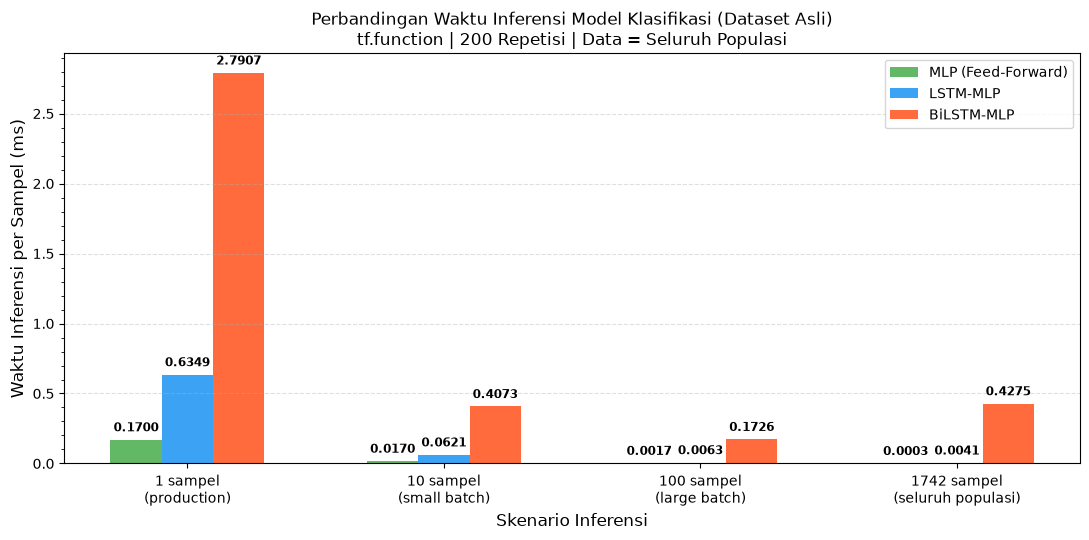

Plot disimpan ke: inference_benchmark.png


In [33]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

x      = np.arange(len(BATCH_SIZES))
width  = 0.2
labels_x = ['1 sampel\n(production)', '10 sampel\n(small batch)',
            '100 sampel\n(large batch)', f'{X.shape[0]} sampel\n(seluruh populasi)']

v_mlp    = [bm_mlp[bs]['per_sample_ms']    for bs in BATCH_SIZES]
v_lstm   = [bm_lstm[bs]['per_sample_ms']   for bs in BATCH_SIZES]
v_bilstm = [bm_bilstm[bs]['per_sample_ms'] for bs in BATCH_SIZES]

fig, ax = plt.subplots(figsize=(11, 5.5))

b1 = ax.bar(x - width, v_mlp,    width, label='MLP (Feed-Forward)', color='#4CAF50', alpha=0.88)
b2 = ax.bar(x,         v_lstm,   width, label='LSTM-MLP',           color='#2196F3', alpha=0.88)
b3 = ax.bar(x + width, v_bilstm, width, label='BiLSTM-MLP',         color='#FF5722', alpha=0.88)

def autolabel(bars):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8.5, fontweight='bold')

autolabel(b1); autolabel(b2); autolabel(b3)

ax.set_xlabel('Skenario Inferensi', fontsize=12)
ax.set_ylabel('Waktu Inferensi per Sampel (ms)', fontsize=12)
ax.set_title(
    'Perbandingan Waktu Inferensi Model Klasifikasi (Dataset Asli)\n'
    'tf.function | 200 Repetisi | Data = Seluruh Populasi',
    fontsize=12
)
ax.set_xticks(x)
ax.set_xticklabels(labels_x, fontsize=10)
ax.legend(fontsize=10)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('inference_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan ke: inference_benchmark.png')


## 12. Ringkasan Akurasi Akhir

In [34]:
print('=' * 60)
print(' RINGKASAN AKURASI MODEL (Test Set)')
print('=' * 60)
acc_summary = pd.DataFrame({
    'Arsitektur Model': ['MLP (Feed-Forward)', 'LSTM-MLP', 'BiLSTM-MLP'],
    'Akurasi Test': [f'{acc_mlp*100:.2f}%', f'{acc_lstm*100:.2f}%', f'{acc_bilstm*100:.2f}%'],
})
display(acc_summary)

best_idx = acc_summary['Akurasi Test'].str.rstrip('%').astype(float).idxmax()
print(f"\nAkurasi tertinggi : {acc_summary.loc[best_idx, 'Arsitektur Model']} ({acc_summary.loc[best_idx, 'Akurasi Test']})")
print(f"MLP     : {acc_mlp*100:.2f}%")
print(f"LSTM    : {acc_lstm*100:.2f}%")
print(f"BiLSTM  : {acc_bilstm*100:.2f}%")


 RINGKASAN AKURASI MODEL (Test Set)


,Arsitektur Model,Akurasi Test
0,MLP (Feed-Forward),74.79%
1,LSTM-MLP,37.82%
2,BiLSTM-MLP,15.19%



Akurasi tertinggi : MLP (Feed-Forward) (74.79%)
MLP     : 74.79%
LSTM    : 37.82%
BiLSTM  : 15.19%


## 13. Kesimpulan Empiris

Benchmark ini menggunakan **dataset asli** (bukan sintetis) dengan pipeline cleaning yang sama
persis dengan `main.ipynb` (moderate cleaning + rule-based keyword mapping P7), sehingga hasil
akurasi dan waktu inferensi merepresentasikan kondisi data production yang sesungguhnya.

**Mengapa MLP lebih cepat?**

1. **Komputasi paralel penuh** — MLP hanya melakukan matrix multiplication + activation function
   yang dapat diparalelkan sepenuhnya oleh hardware.

2. **LSTM memiliki recurrent loop** — setiap time step harus menunggu output step sebelumnya
   (sequential dependency), menyebabkan overhead yang tidak bisa dihilangkan meski dengan batching.

3. **BiLSTM dua kali lebih berat** — menjalankan dua LSTM secara paralel (forward + backward),
   sehingga waktu inferensinya lebih tinggi dari LSTM unidirectional.

4. **Pada single sample (skenario production nyata)**, selisih paling terasa karena overhead
   recurrent computation tidak ter-amortisasi oleh batch size besar. Bahkan pada skenario
   seluruh populasi diproses sekaligus, MLP tetap unggul dari sisi throughput per sampel.

Hasil ini memberikan justifikasi teknis — dilengkapi metrik akurasi (`classification_report`)
di atas — untuk memilih arsitektur yang paling optimal antara trade-off kecepatan inferensi
dan akurasi klasifikasi pada sistem berbasis TF-IDF dalam lingkungan production.